# OpenML Evaluation — View Results & Plots

Single notebook to **choose a dataset and model**, then either:
1. **Load** saved performance and plots (from `scripts/run_openml_evaluation.py`), or
2. **Run** evaluation for the selected dataset and then view results.

Performance JSON files: `results/evaluation/{nam,ebm}_OpenML_{id}_{task}_performance.json`  
Plots (if generated): `results/evaluation/plots/{nam,ebm}_OpenML_{id}_{task}/`

In [1]:
# ============================================================================
# CONFIGURATION — Change these to view a different dataset/model
# ============================================================================
OPENML_DATASET_ID = 1067
TASK_TYPE = "classification"   # "classification" or "regression"
MODEL_TYPE = "NAM"              # "NAM" or "EBM"

In [2]:
import json
from pathlib import Path
import numpy as np

project_root = Path.cwd().parent.parent
results_dir = project_root / 'results' / 'evaluation'
plots_base = results_dir / 'plots'

dataset_name = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
perf_file = results_dir / f"{MODEL_TYPE.lower()}_{dataset_name}_performance.json"
plots_dir = plots_base / f"{MODEL_TYPE.lower()}_{dataset_name}"

print(f"Dataset: {dataset_name}")
print(f"Model: {MODEL_TYPE}")
print(f"Performance file: {perf_file}")
print(f"Exists: {perf_file.exists()}")
print(f"Plots dir: {plots_dir}")
print(f"Exists: {plots_dir.exists()}")

Dataset: OpenML_1067_classification
Model: NAM
Performance file: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\nam_OpenML_1067_classification_performance.json
Exists: True
Plots dir: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\plots\nam_OpenML_1067_classification
Exists: True


## Load and display performance summary

In [3]:
if perf_file.exists():
    with open(perf_file, 'r') as f:
        perf = json.load(f)
    summary = perf.get('summary', {})
    metric_name = summary.get('metric_name', 'metric')
    print(f"Mean {metric_name}: {summary.get('mean_metric', 'N/A'):.4f}")
    print(f"Std {metric_name}:  {summary.get('std_metric', 'N/A'):.4f}")
    print(f"Min / Max: {summary.get('min_metric', 'N/A'):.4f} / {summary.get('max_metric', 'N/A'):.4f}")
    print("\nPer-fold:")
    for fold in perf.get('folds', []):
        print(f"  Fold {fold['fold']}: {metric_name} = {fold['metric_value']:.4f} (n={fold['test_set_size']})")
else:
    print("No performance file found. Run evaluation first:")
    print(f"  python scripts/run_openml_evaluation.py --dataset_id {OPENML_DATASET_ID} --task_type {TASK_TYPE} --model {MODEL_TYPE} --save_plots")

Mean AUC: 0.7973
Std AUC:  0.0172
Min / Max: 0.7762 / 0.8173

Per-fold:
  Fold 1: AUC = 0.8173 (n=422)
  Fold 2: AUC = 0.7782 (n=422)
  Fold 3: AUC = 0.8130 (n=422)
  Fold 4: AUC = 0.8021 (n=422)
  Fold 5: AUC = 0.7762 (n=421)


## Display saved plots

feature_importance_across_splits.png


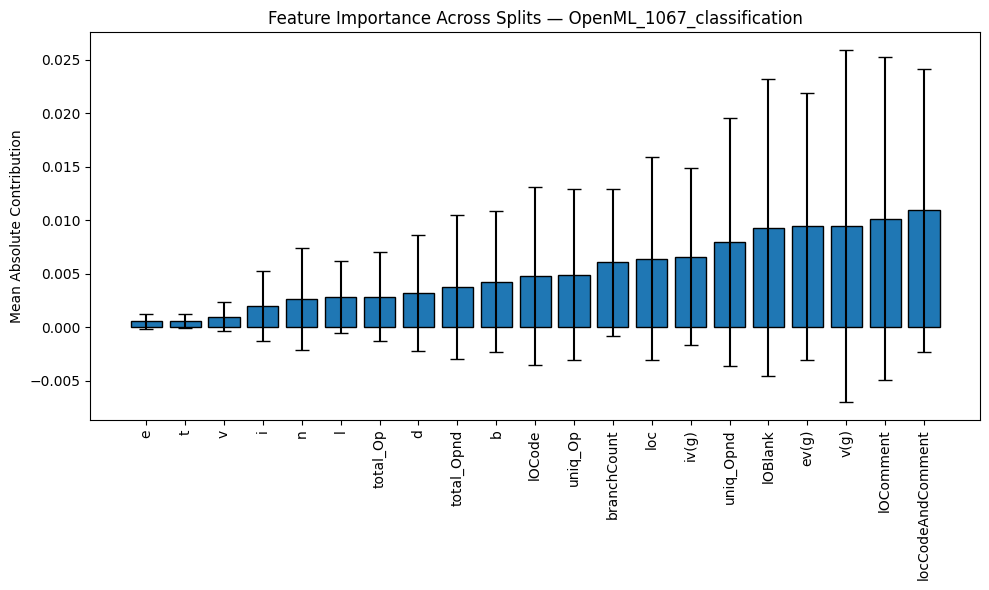

nam_contributions_with_density.png


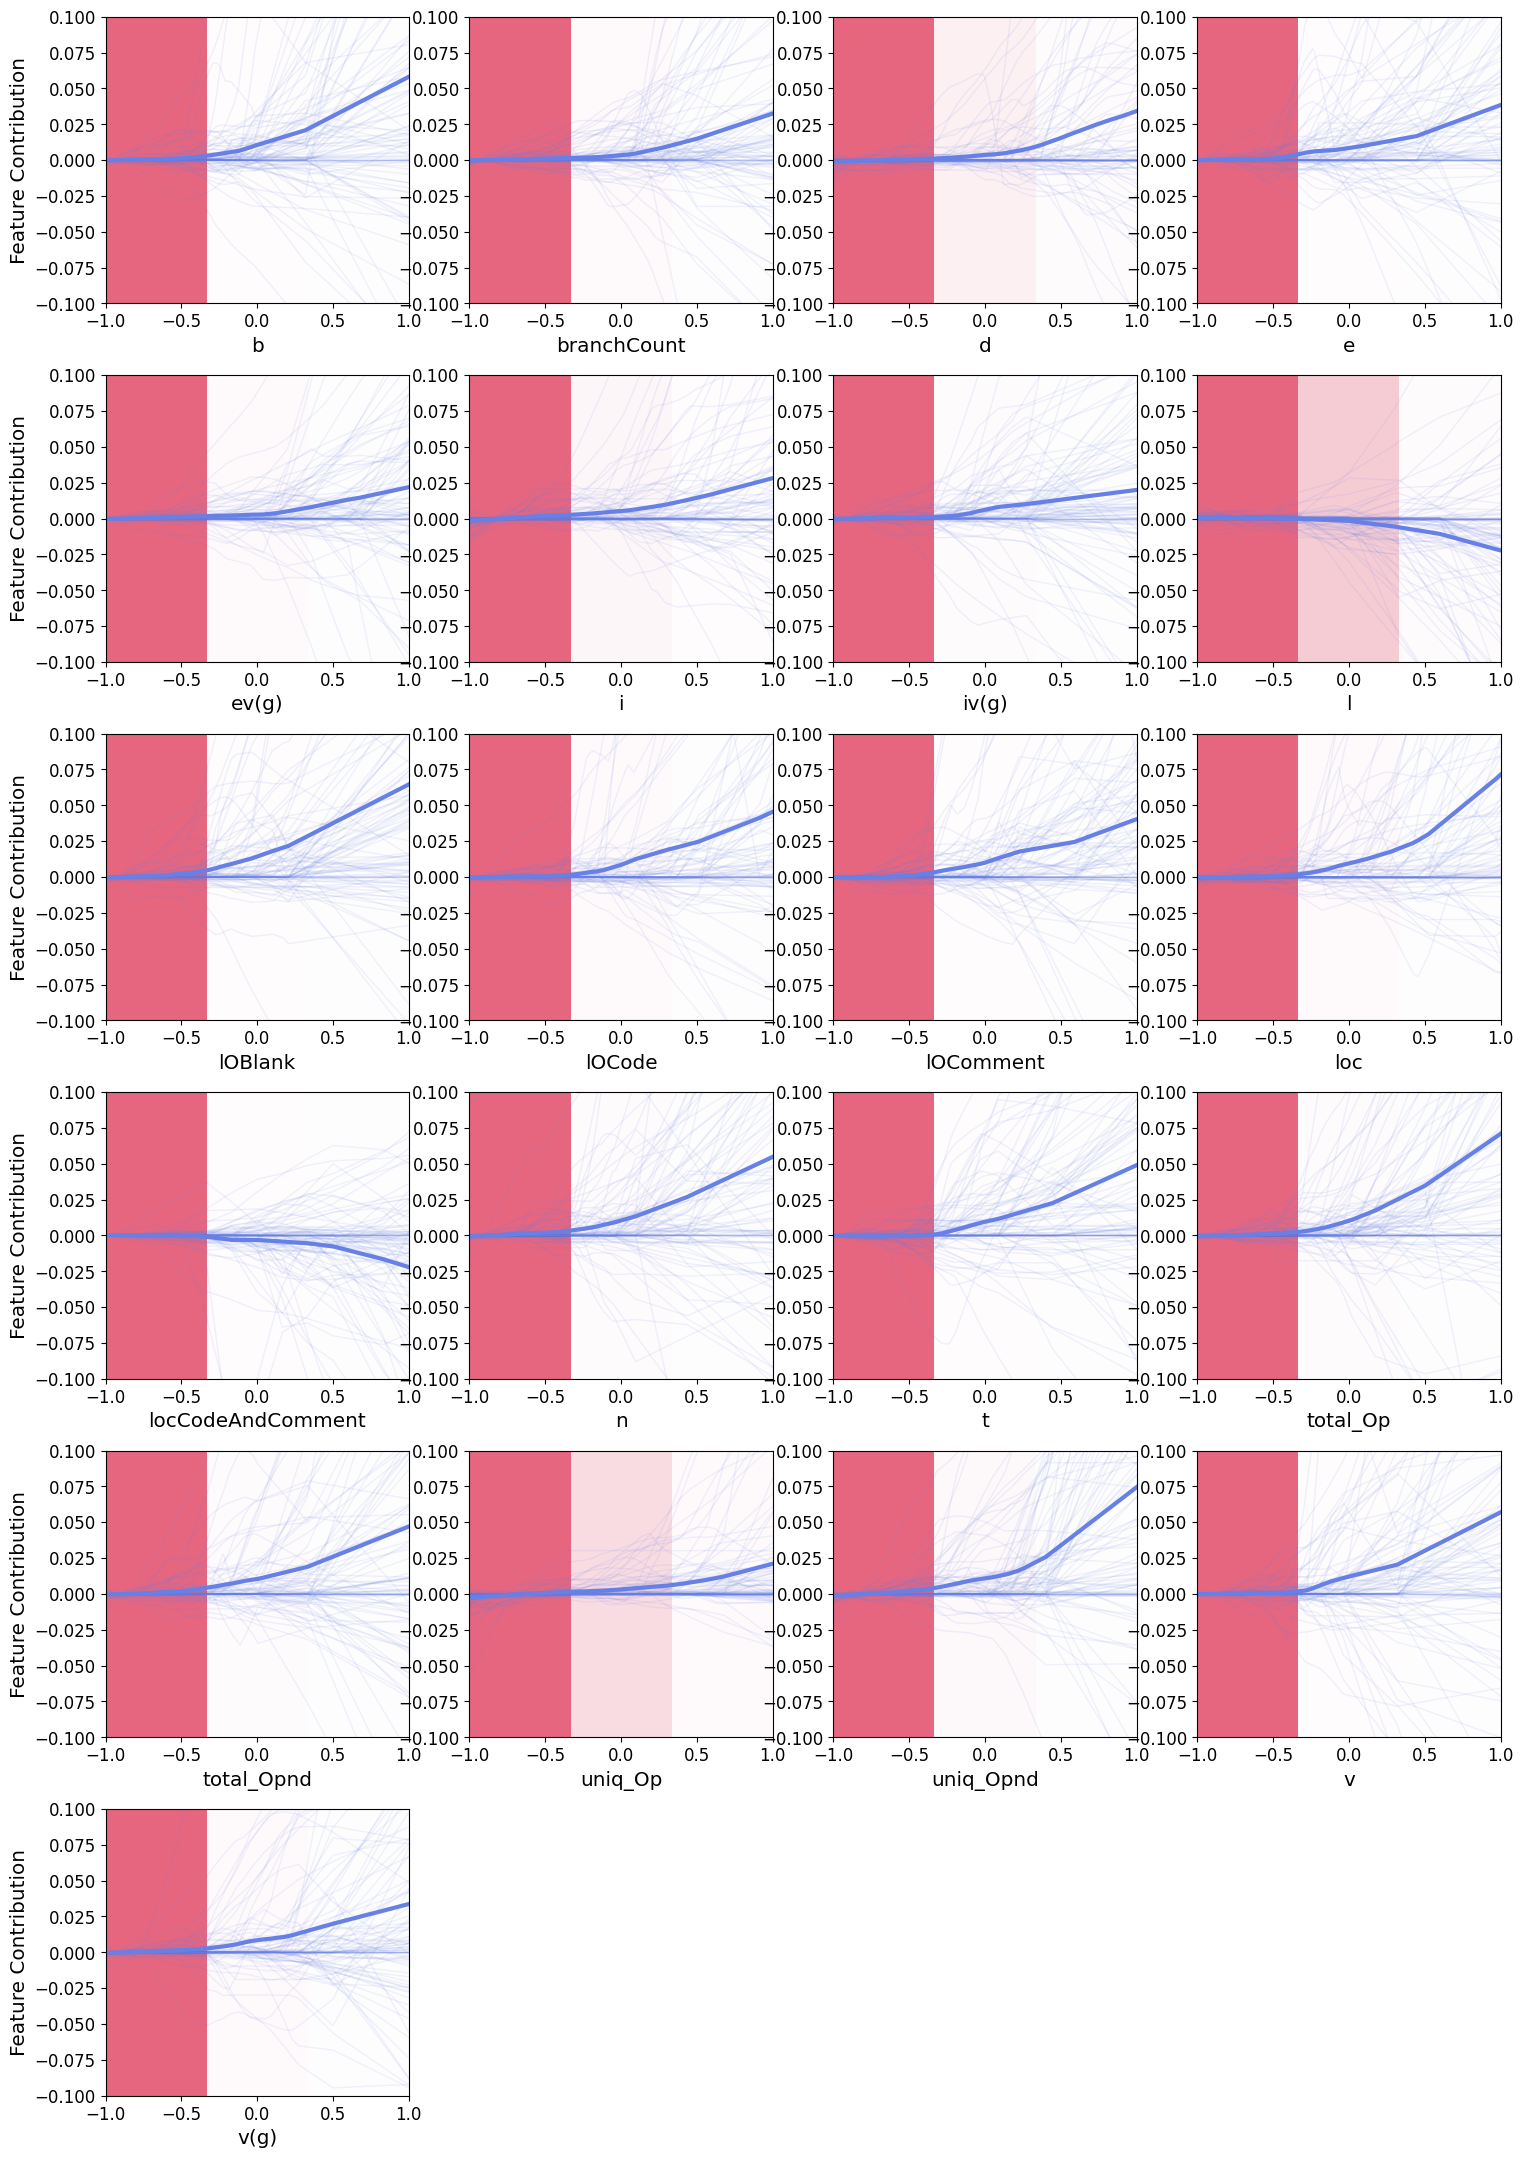

In [4]:
from IPython.display import Image, display

if plots_dir.exists():
    for p in sorted(plots_dir.glob('*.png')):
        print(p.name)
        display(Image(filename=str(p)))
else:
    print("No saved plots. Run with --save_plots:")
    print(f"  python scripts/run_openml_evaluation.py --dataset_id {OPENML_DATASET_ID} --task_type {TASK_TYPE} --model {MODEL_TYPE} --save_plots")